# Project Milestone 5
* Data Preparation: DSC 540-T302 
* Mallory Young
* Student #21356619

## Loading Data into a Database
For my project, each Milestone was saved in a separate .ipynb jupyter notebook file. I used the syntax: _df.to_csv('film_revenue_data.csv', index=False)_ to save each of my cleansed datasets as a .csv file. 

I used the DB Browser for SQLite application to load my 3 csv files into a database titled "FilmDB". The 3 tables within the database created from my 3 milestone csv files are the following: 
* FilmNom - Contains the Wikipedia website data for Academy Award film nominations and wins.
* Holywd_gross - Contains the flat file data for the 1000 highest grossing movies.
* Film_revenue - Contains the TMDB API data for films with the highest revenue.

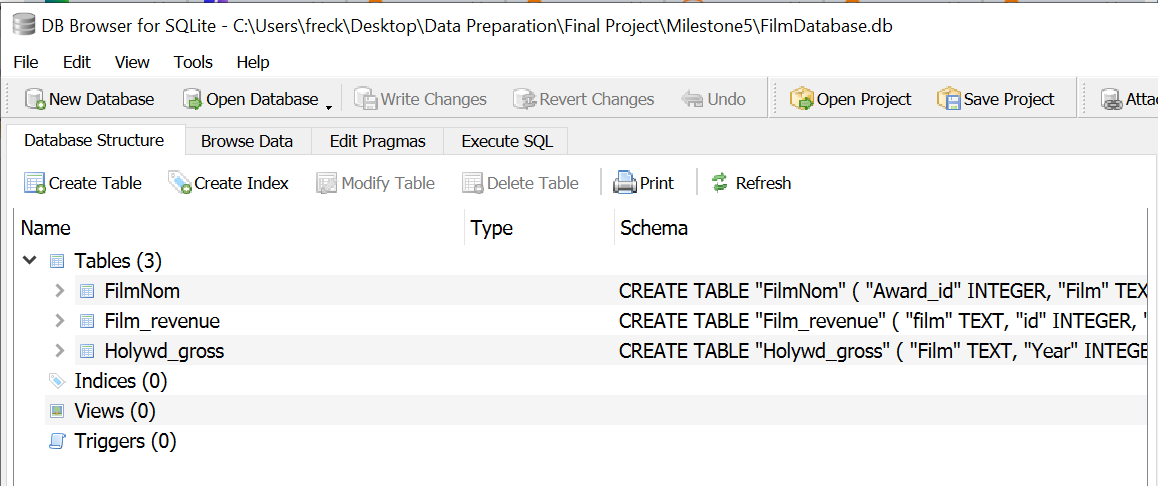

## Connecting to the Database
Connecting to the 'FilmDB' database and checking whether the connection has been successful. 

In [1]:
#importing the sqlite3 and os.path libraries from Python
import sqlite3
import os.path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
#Return a string representing the current working directory
os.getcwd()

'C:\\Users\\freck\\Desktop\\Data Preparation\\Final Project\\Milestone5'

In [3]:
#using the connect() function to connect to a database
conn = sqlite3.connect("C:\\Users\\freck\\Desktop\\Data Preparation\\Final Project\\Milestone5\\FilmDB.db")  

In [4]:
#creating a cursor object to execute SQL queries within the 'FilmDatabase' database
cursor = conn.cursor()

In [5]:
#a function that checks whether the connection has been successful
#the function uses a try/except to test the connection
def database_opened(conn):
    #try executes a SQL query to select all columns from the "FilmNom" table, but limiting the result to one row
    try:
        conn.execute("SELECT * FROM FilmNom LIMIT 1")
        #If the query is successful, 'True' is returned
        return True
    #except executes if an exception occurs during the SQL query
    except sqlite3.ProgrammingError as e:
        #a string is printed with the specific error message obtained from the exception e
        print("Connection unsuccessful {}".format(e))
        #if the query raises an exception, 'False' is returned
        return False

#calling the database_opened() function with the 'conn' argument, and the result is printed to the console.
print(database_opened(conn))

True


In [6]:
#selecting the first 10 rows of the "FilmNom" table to see verify the table data was successfully loaded into the database
rows = cursor.execute('SELECT * FROM FilmNom LIMIT 10')
#using a for loop to iterate through and print the rows in the FilmNom table 
for row in rows:
    print(row)

(1372, 'Oppenheimer', 2023, 7, 13, 'True')
(1366, 'Godzilla Minus One', 2023, 1, 1, 'False')
(1360, 'Poor Things', 2023, 4, 11, 'False')
(1361, 'The Zone of Interest', 2023, 2, 5, 'False')
(1362, 'American Fiction', 2023, 1, 5, 'False')
(1364, 'Barbie', 2023, 1, 8, 'False')
(1365, 'The Last Repair Shop', 2023, 1, 1, 'False')
(1363, 'Anatomy of a Fall', 2023, 1, 5, 'False')
(1367, 'The Holdovers', 2023, 1, 5, 'False')
(1368, '20 Days in Mariupol', 2023, 1, 1, 'False')


## Joining the 3 Tables into 1 Dataset

#### SQL Database Query #1: 
First, I will join all three tables using an implicit inner join. This join uses sql (without pandas) to complete the join. 

In [7]:
#writing an sql query to join the 3 tables
#retrieving all columns from the "FilmNom" table and combines the data with the "Holywd_gross" and "Film_revenue" tables 
#based on the "Year" column in each table. 
#Limiting the query to 25 rows to avoid crashing jupyter notebook
sql = """
SELECT * FROM FilmNom 
JOIN Holywd_gross ON FilmNom.Year = Holywd_gross.Year 
JOIN Film_revenue ON FilmNom.Year = Film_revenue.Year
LIMIT 25"""

#Executing the query
rows = cursor.execute(sql)
#printing the result set data
for row in rows:
    print(row)

(1372, 'Oppenheimer', 2023, 7, 13, 'True', 'Ant-Man and the Wasp: Quantumania', 2023, '20-Jun-75', "['Adventure', 'Mystery', 'Thriller']", None, 'Walt Disney Studios Motion Pictures', '2 hr 4 min', "Scott Lang and Hope Van Dyne are dragged into the Quantum Realm, along with Hope's parents and Scott's daughter Cassie. Together they must find a way to escape, but what secrets is Hope's mother hiding? And who is the mysterious Kang?", None, '$106,109,650.00', '$214,504,909.00', '$261,566,271.00', '$476,071,180.00', 'Barbie', 346698, 2023, '2023-07-19', 'English', '[35, 12]', 'United Kingdom, United States of America', '$1,445,638,421.00', '$-145,000,000.00', 209.639, 8689, 7.036, 'Released', "She's everything. He's just Ken.", 'Barbie and Ken are having the time of their lives in the colorful and seemingly perfect world of Barbie Land. However, when they get a chance to go to the real world, they soon discover the joys and perils of living among humans.', 114)
(1372, 'Oppenheimer', 2023, 

Next, I will complete this same join for all 3 tables. But, this time I will save the data in a Pandas DataFrame to be used when creating a visualization of the data. 

In [8]:
#writing an sql query to join the 3 tables
query = """
SELECT * FROM FilmNom 
JOIN Holywd_gross ON FilmNom.Year = Holywd_gross.Year 
JOIN Film_revenue ON FilmNom.Year = Film_revenue.Year
"""

#executing the query and retrieve the result into a pandas DataFrame
all3_df = pd.read_sql_query(query, conn)
#printing the 'all3_df' dataframe
all3_df

,Award_id,Film,Year,Awards,Nominations,Best Picture Winner,Film,Year,Release Date,Genre,...,production_countries,revenue (USD),budget (USD),popularity,vote_count,vote_average,release_status,tagline,plot,runtime (min)
0,1372,Oppenheimer,2023,7,13,True,Ant-Man and the Wasp: Quantumania,2023,20-Jun-75,"['Adventure', 'Mystery', 'Thriller']",...,"United Kingdom, United States of America","$1,445,638,421.00","$-145,000,000.00",209.639,8689,7.036,Released,She's everything. He's just Ken.,Barbie and Ken are having the time of their li...,114
1,1372,Oppenheimer,2023,7,13,True,Ant-Man and the Wasp: Quantumania,2023,20-Jun-75,"['Adventure', 'Mystery', 'Thriller']",...,"Japan, United States of America","$1,362,000,000.00","$-100,000,000.00",296.538,8755,7.664,Released,Not all heroes wear capes. Some wear overalls.,"While working underground to fix a water main,...",93
2,1372,Oppenheimer,2023,7,13,True,Barbie,2023,20-Nov-19,"['Adventure', 'Animation', 'Comedy', 'Drama', ...",...,"United Kingdom, United States of America","$1,445,638,421.00","$-145,000,000.00",209.639,8689,7.036,Released,She's everything. He's just Ken.,Barbie and Ken are having the time of their li...,114
3,1372,Oppenheimer,2023,7,13,True,Barbie,2023,20-Nov-19,"['Adventure', 'Animation', 'Comedy', 'Drama', ...",...,"Japan, United States of America","$1,362,000,000.00","$-100,000,000.00",296.538,8755,7.664,Released,Not all heroes wear capes. Some wear overalls.,"While working underground to fix a water main,...",93
4,1372,Oppenheimer,2023,7,13,True,Creed III,2023,9-Nov-12,"['Biography', 'Drama', 'History', 'War']",...,"United Kingdom, United States of America","$1,445,638,421.00","$-145,000,000.00",209.639,8689,7.036,Released,She's everything. He's just Ken.,Barbie and Ken are having the time of their li...,114
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9721,994,Men in Black,1997,1,3,False,The Fifth Element,1997,3-Nov-00,"['Action', 'Adventure', 'Comedy', 'Crime', 'Th...",...,United States of America,"$2,264,162,353.00","$-200,000,000.00",206.498,24922,7.906,Released,Nothing on Earth could come between them.,101-year-old Rose DeWitt Bukater tells the sto...,194
9722,994,Men in Black,1997,1,3,False,The Full Monty,1997,15-Aug-97,"['Comedy', 'Drama']",...,United States of America,"$2,264,162,353.00","$-200,000,000.00",206.498,24922,7.906,Released,Nothing on Earth could come between them.,101-year-old Rose DeWitt Bukater tells the sto...,194
9723,994,Men in Black,1997,1,3,False,The Lost World: Jurassic Park,1997,23-May-97,"['Action', 'Adventure', 'Sci-Fi']",...,United States of America,"$2,264,162,353.00","$-200,000,000.00",206.498,24922,7.906,Released,Nothing on Earth could come between them.,101-year-old Rose DeWitt Bukater tells the sto...,194
9724,994,Men in Black,1997,1,3,False,Titanic,1997,19-Dec-97,"['Drama', 'Romance']",...,United States of America,"$2,264,162,353.00","$-200,000,000.00",206.498,24922,7.906,Released,Nothing on Earth could come between them.,101-year-old Rose DeWitt Bukater tells the sto...,194


### Visualization 1: Heat Map
The following visualization is a heat map of the numerical columns for the joined 3 datasets. It shows data from  By exclusively focusing on numerical values, this heat map enables the identification of relationships (such as correlations and patterns) between various movie-related metrics such as ratings, budgets, and genre frequencies. Numerical data from all 3 datasets is represented in this visualization. 

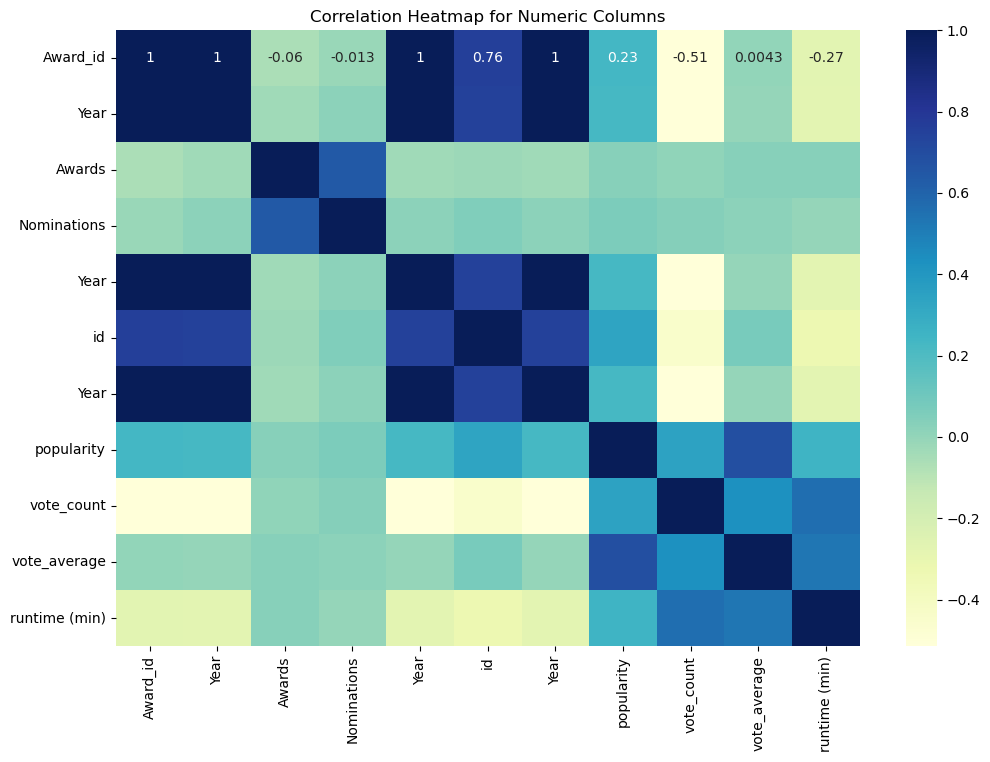

In [9]:
#selecting only the numeric columns from the dataframe and assign the selection to a variable
numeric_columns = all3_df.select_dtypes(include=[np.number])

#creating a correlation matrix for the numeric columns
correlation_matrix = numeric_columns.corr()

#setting the figure size for the heatmap
plt.figure(figsize=(12, 8))
#creating the heatmap with annotations and a specific color map that ranges from yellow (Yl) to green (Gn) to blue (Bu)
sns.heatmap(correlation_matrix, annot=True, cmap="YlGnBu")
#setting a title for the heatmap
plt.title('Correlation Heatmap for Numeric Columns')
#displaying the heatmap with the specified figure size, title, annotations, and color map ranges
plt.show()

## Joining 2 Tables into 1 Dataset
**The next two sets of visualizations will be created using different combinations of joins between 2 of the 3 datasets.** 

#### SQL Database Query #2: 
First, I will join the _Holywd_gross_ table with the _FilmNom_ table using an inner join. In this join I have specified the specific column names from each table that I wish to query. This join uses sql (without pandas) to complete the join.

In [10]:
#writing an sql query to join the 2 tables
#retrieving specified columns from the tables FilmNom and Holywd_gross by joining them based on the 'Film' column
sql2 = """
SELECT FilmNom.Award_id, FilmNom.Film, FilmNom.Year, FilmNom.Awards, Holywd_gross.rating, Holywd_gross.Distributor
FROM FilmNom
JOIN Holywd_gross
ON FilmNom.Film = Holywd_gross.Film"""

#executing the query
rows = cursor.execute(sql2)
#printing the result set data
for row in rows:
    print(row)

(1372, 'Oppenheimer', 2023, 7, 'PG', 'Universal Pictures')
(1364, 'Barbie', 2023, 1, 'PG', 'Warner Bros.')
(1349, 'Top Gun: Maverick', 2022, 1, 'PG-13', 'Paramount Pictures')
(1350, 'Black Panther: Wakanda Forever', 2022, 1, 'PG-13', 'Walt Disney Studios Motion Pictures')
(1351, 'Avatar: The Way of Water', 2022, 1, 'PG-13', '20th Century Studios')
(1333, 'Dune', 2021, 6, 'PG-13', 'Warner Bros.')
(1336, 'No Time to Die', 2021, 1, 'PG', 'Metro-Goldwyn-Mayer (MGM)')
(1341, 'Encanto', 2021, 1, 'R', 'Walt Disney Studios Motion Pictures')
(1345, 'Cruella', 2021, 1, 'PG-13', 'Walt Disney Studios Motion Pictures')
(1325, 'Tenet', 2020, 1, 'PG', 'Warner Bros.')
(1301, 'Parasite', 2019, 4, 'R', 'Neon')
(1302, 'Ford v Ferrari', 2019, 2, 'PG-13', 'Twentieth Century Fox')
(1305, 'Little Women', 2019, 1, 'PG', 'Sony Pictures Entertainment (SPE)')
(1308, 'Toy Story 4', 2019, 1, 'G', 'Walt Disney Studios Motion Pictures')
(1309, 'Joker', 2019, 2, 'R', 'Warner Bros.')
(1310, 'Once Upon a Time in Hollyw

Next, I will complete this same join for the 2 tables (_Holywd_gross_ and _FilmNom_). But, this time I will save the data in a Pandas DataFrame to be used when creating a visualization of the data. 

In [11]:
#writing an sql query to join the 2 tables
query2 = """
SELECT FilmNom.Award_id, FilmNom.Film, FilmNom.Year, FilmNom.Awards, Holywd_gross.rating, Holywd_gross.Distributor
FROM FilmNom
JOIN Holywd_gross
ON FilmNom.Film = Holywd_gross.Film"""

#executing the query and retrieve the result into a pandas DataFrame
gross_Nom_df = pd.read_sql_query(query2, conn)
#printing the 'gross_Nom_df' dataframe
gross_Nom_df

,Award_id,Film,Year,Awards,Rating,Distributor
0,1372,Oppenheimer,2023,7,PG,Universal Pictures
1,1364,Barbie,2023,1,PG,Warner Bros.
2,1349,Top Gun: Maverick,2022,1,PG-13,Paramount Pictures
3,1350,Black Panther: Wakanda Forever,2022,1,PG-13,Walt Disney Studios Motion Pictures
4,1351,Avatar: The Way of Water,2022,1,PG-13,20th Century Studios
...,...,...,...,...,...,...
178,121,Gone with the Wind,1939,8,R,Metro-Goldwyn-Mayer (MGM)
179,90,Snow White and the Seven Dwarfs,1937,0,PG-13,Walt Disney Studios Motion Pictures
180,103,A Star Is Born,1937,1,R,Warner Bros.
181,49,Little Women,1932,1,PG,Sony Pictures Entertainment (SPE)


### Visualization 2: Pie Chart
The following visualization is a pie chart displaying the distribution of film awards (from the _FilmNom_ table) among different film distributors (from the _Holywd_gross_ table). Each slice of the pie represents a film distributor, and the size of each slice corresponds to the percentage of awards received by that film distributor. 

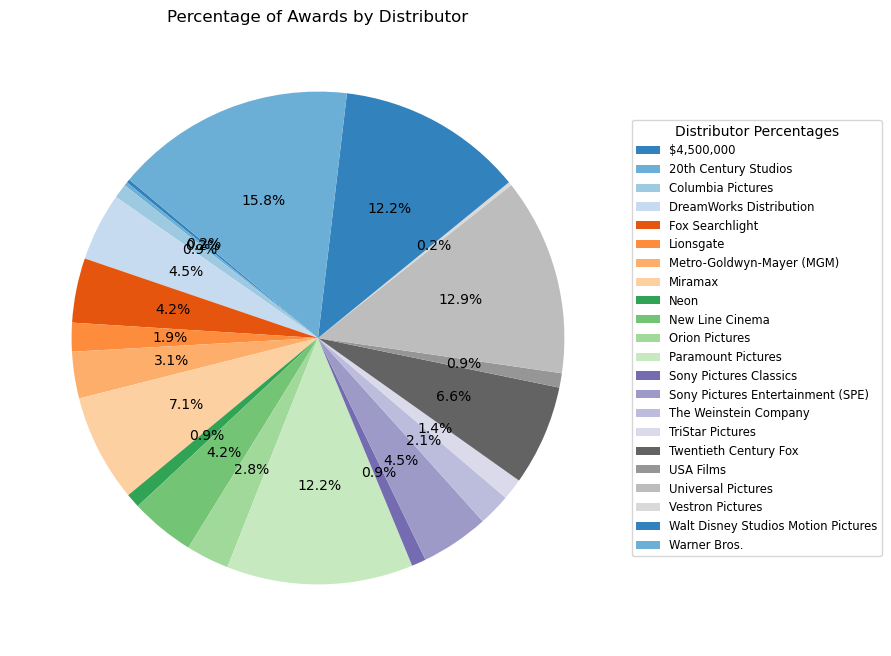

In [12]:
#calculating the percentage of awards for each distributor
#groupby groups the data by the 'Distributor' column, then applies the sum function to calculate the total awards for each distributor
#dividing the sum of awards for each distributor by the total sum of awards
#then, multiplying the proportions by 100 to convert them into percentages
percentage_awards = (gross_Nom_df.groupby('Distributor')['Awards'].sum() / gross_Nom_df['Awards'].sum()) * 100

#setting the size of the figure to 10 inches in width and 8 inches in height
plt.figure(figsize=(10, 8))
#creating a pie chart with the calculated percentage awards
#Setting labels to None, start angle to 140, colors to a predefined color map, and display percentage values with one decimal place
pie_chart = plt.pie(percentage_awards, labels=None, startangle=140, colors=plt.cm.tab20c.colors, autopct='%1.1f%%')
#adding a legend with percentages and position it off to the side
plt.legend(percentage_awards.index, loc='center left', bbox_to_anchor=(1, 0.5), title='Distributor Percentages', fontsize='small')
#setting a title for the pie chart
plt.title('Percentage of Awards by Distributor')
#display the plot with the specified figure size, pie chart, title, and legend
plt.show()

#### SQL Database Query #3: 
Next, I will join the _Film_revenue_ table with the _FilmNom_ table using an inner join. This join uses sql (without pandas) to complete the join.

In [13]:
#writing an sql query to join the 2 tables
#retrieving all columns from both the 'FilmNom' and 'Film_revenue' tables with FilmNom as the primary table
#performing an inner join between the 'FilmNom' and 'Film_revenue' tables based on the 'Year' column.
sql3 = """
SELECT FilmNom.*, Film_revenue.*
FROM FilmNom
INNER JOIN Film_revenue ON FilmNom.Year = Film_revenue.Year
"""
#executing the query
cursor.execute(sql3)

#This has query/join has a lot of rows, so I am only printing the first 5 rows. 
num_rows_to_fetch = 5  # Specify the number of rows to fetch
result = cursor.fetchmany(num_rows_to_fetch)

#printing the result set data
for row in result:
    print(row)

(1372, 'Oppenheimer', 2023, 7, 13, 'True', 'Barbie', 346698, 2023, '2023-07-19', 'English', '[35, 12]', 'United Kingdom, United States of America', '$1,445,638,421.00', '$-145,000,000.00', 209.639, 8689, 7.036, 'Released', "She's everything. He's just Ken.", 'Barbie and Ken are having the time of their lives in the colorful and seemingly perfect world of Barbie Land. However, when they get a chance to go to the real world, they soon discover the joys and perils of living among humans.', 114)
(1372, 'Oppenheimer', 2023, 7, 13, 'True', 'The Super Mario Bros. Movie', 502356, 2023, '2023-04-05', 'English', '[16, 10751, 12, 14, 35]', 'Japan, United States of America', '$1,362,000,000.00', '$-100,000,000.00', 296.538, 8755, 7.664, 'Released', 'Not all heroes wear capes. Some wear overalls.', 'While working underground to fix a water main, Brooklyn plumbers—and brothers—Mario and Luigi are transported down a mysterious pipe and wander into a magical new world. But when the brothers are separa

I will complete this same join for the 2 tables (_Film_revenue_ and _FilmNom_). But, this time I will save the data in a Pandas DataFrame to be used when creating a visualization of the data. 

In [14]:
#writing an sql query to join the 2 tables
query3 = """
SELECT * FROM FilmNom
INNER JOIN Film_revenue ON FilmNom.year = Film_revenue.year"""

#executing the query and retrieve the result into a pandas DataFrame
revenue_Nom_df = pd.read_sql_query(query3, conn)
#printing the 'gross_Nom_df' dataframe
revenue_Nom_df

,Award_id,Film,Year,Awards,Nominations,Best Picture Winner,Film,id,Year,release_date,...,production_countries,revenue (USD),budget (USD),popularity,vote_count,vote_average,release_status,tagline,plot,runtime (min)
0,1372,Oppenheimer,2023,7,13,True,Barbie,346698,2023,2023-07-19,...,"United Kingdom, United States of America","$1,445,638,421.00","$-145,000,000.00",209.639,8689,7.036,Released,She's everything. He's just Ken.,Barbie and Ken are having the time of their li...,114
1,1372,Oppenheimer,2023,7,13,True,The Super Mario Bros. Movie,502356,2023,2023-04-05,...,"Japan, United States of America","$1,362,000,000.00","$-100,000,000.00",296.538,8755,7.664,Released,Not all heroes wear capes. Some wear overalls.,"While working underground to fix a water main,...",93
2,1366,Godzilla Minus One,2023,1,1,False,Barbie,346698,2023,2023-07-19,...,"United Kingdom, United States of America","$1,445,638,421.00","$-145,000,000.00",209.639,8689,7.036,Released,She's everything. He's just Ken.,Barbie and Ken are having the time of their li...,114
3,1366,Godzilla Minus One,2023,1,1,False,The Super Mario Bros. Movie,502356,2023,2023-04-05,...,"Japan, United States of America","$1,362,000,000.00","$-100,000,000.00",296.538,8755,7.664,Released,Not all heroes wear capes. Some wear overalls.,"While working underground to fix a water main,...",93
4,1360,Poor Things,2023,4,11,False,Barbie,346698,2023,2023-07-19,...,"United Kingdom, United States of America","$1,445,638,421.00","$-145,000,000.00",209.639,8689,7.036,Released,She's everything. He's just Ken.,Barbie and Ken are having the time of their li...,114
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259,990,Visas and Virtue,1997,1,1,False,Titanic,597,1997,1997-11-18,...,United States of America,"$2,264,162,353.00","$-200,000,000.00",206.498,24922,7.906,Released,Nothing on Earth could come between them.,101-year-old Rose DeWitt Bukater tells the sto...,194
260,992,Geri's Game,1997,1,1,False,Titanic,597,1997,1997-11-18,...,United States of America,"$2,264,162,353.00","$-200,000,000.00",206.498,24922,7.906,Released,Nothing on Earth could come between them.,101-year-old Rose DeWitt Bukater tells the sto...,194
261,993,The Long Way Home,1997,1,1,False,Titanic,597,1997,1997-11-18,...,United States of America,"$2,264,162,353.00","$-200,000,000.00",206.498,24922,7.906,Released,Nothing on Earth could come between them.,101-year-old Rose DeWitt Bukater tells the sto...,194
262,991,Character (Karakter),1997,1,1,False,Titanic,597,1997,1997-11-18,...,United States of America,"$2,264,162,353.00","$-200,000,000.00",206.498,24922,7.906,Released,Nothing on Earth could come between them.,101-year-old Rose DeWitt Bukater tells the sto...,194


### Visualization 3: Bar Chart
The following visualization is a bar chart displaying how many Academy Awards a film won (from the _FilmNom_ table) compared to the its popularity rating (from the _Film_revenue_ table). This visualization is useful in showing that maybe not all of the award winning films were necessarily the most popularly rated films. 

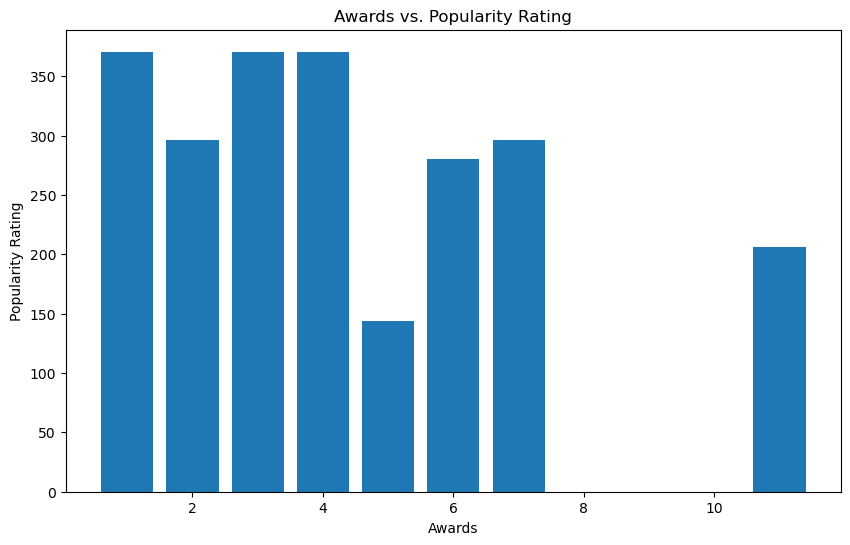

In [15]:
#setting the size of the figure to 10 inches in width and 8 inches in height
plt.figure(figsize=(10, 6))
#creating a bar chart using the data in the 'Awards' and 'Title' columns
plt.bar(revenue_Nom_df['Awards'], revenue_Nom_df['popularity'])
#setting a title for the bar chart
plt.title('Awards vs. Popularity Rating')
#setting the labels for the x and y axes
plt.xlabel('Awards')
plt.ylabel('Popularity Rating')
#display the plot with the specified figure size, bar chart, title, and axis labels
plt.show()

## Querying Data from 1 Dataset
**The next two sets of visualizations will be created by querying from a single table in the database.** 

#### SQL Database Query #4: 

This is a sql query of the _Holywd_gross_ data table from the database. The sql query groups the data by the "Year" column. (Pandas is not used for this query)

In [16]:
#writing an sql query to pull the FilmNom table data
#using a SELECT * to select all of the table data 
#using GROUP BY to group the data by the "Year" column
sql4 = """SELECT * FROM Holywd_gross GROUP BY Year"""

#executing the query
rows = cursor.execute(sql4)
#printing the result set data
for row in rows:
    print(row)

('Snow White and the Seven Dwarfs', 1937, '18-May-01', "['Drama', 'Musical', 'Romance']", 'PG-13', 'Walt Disney Studios Motion Pictures', '2 hr 7 min', 'Exiled into the dangerous forest by her wicked stepmother, a princess is rescued by seven dwarf miners who make her part of their household.', None, '$1,499,000.00', '$184,925,486.00', '$184,925,486.00', '$184,928,542.00')
('Gone with the Wind', 1939, '30-May-12', "['Adventure', 'Mystery', 'Sci-Fi']", 'R', 'Metro-Goldwyn-Mayer (MGM)', '2 hr 4 min', 'A sheltered and manipulative Southern belle and a roguish profiteer face off in a turbulent romance as the society around them crumbles with the end of slavery and is rebuilt during the Civil War and Reconstruction periods.', '$130,000,000.00', None, '$200,882,193.00', '$201,500,000.00', '$402,382,193.00')
('Bambi', 1942, '4-Oct-17', "['Action', 'Drama', 'Mystery', 'Sci-Fi', 'Thriller']", 'R', 'RKO Radio Pictures', '2 hr 44 min', 'The story of a young deer growing up in the forest.', '$150,

This is the same query of the _Holywd_gross_ table but, this time I will save the data in a Pandas DataFrame to be used when creating a visualization of the data. 

In [17]:
#writing an sql query to join the 2 tables
query4 = """SELECT * FROM Holywd_gross GROUP BY Year"""

#executing the query and retrieve the result into a pandas DataFrame
Film_revenue_df = pd.read_sql_query(query4, conn)
#printing the 'Film_revenue_df' dataframe
Film_revenue_df

,Film,Year,Release Date,Genre,Rating,Distributor,Running Time,Movie Info,Budget,Domestic Opening,Domestic Sales,International Sales (USD),World Wide Sales (USD)
0,Snow White and the Seven Dwarfs,1937,18-May-01,"['Drama', 'Musical', 'Romance']",PG-13,Walt Disney Studios Motion Pictures,2 hr 7 min,Exiled into the dangerous forest by her wicked...,None,"$1,499,000.00","$184,925,486.00","$184,925,486.00","$184,928,542.00"
1,Gone with the Wind,1939,30-May-12,"['Adventure', 'Mystery', 'Sci-Fi']",R,Metro-Goldwyn-Mayer (MGM),2 hr 4 min,A sheltered and manipulative Southern belle an...,"$130,000,000.00",None,"$200,882,193.00","$201,500,000.00","$402,382,193.00"
2,Bambi,1942,4-Oct-17,"['Action', 'Drama', 'Mystery', 'Sci-Fi', 'Thri...",R,RKO Radio Pictures,2 hr 44 min,The story of a young deer growing up in the fo...,"$150,000,000.00",None,"$102,247,150.00","$165,200,000.00","$267,447,150.00"
3,One Hundred and One Dalmatians,1961,5-Aug-94,"['Action', 'Crime', 'Drama', 'Thriller']",PG-13,Walt Disney Studios Motion Pictures,2 hr 21 min,When a litter of Dalmatian puppies are abducte...,"$62,000,000.00",None,"$144,880,014.00","$71,000,000.00","$215,880,014.00"
4,The Jungle Book (Remake),1967,5-Dec-06,"['Comedy', 'Romance']",PG-13,Walt Disney Studios Motion Pictures,2 hr 16 min,Bagheera the Panther and Baloo the Bear have a...,"$85,000,000.00",None,"$141,843,612.00","$64,000,000.00","$205,843,612.00"
5,The Godfather,1972,15-Mar-72,"['Crime', 'Drama']",None,Paramount Pictures,2 hr 55 min,"Don Vito Corleone, head of a mafia family, dec...","$6,000,000.00","$302,393.00","$136,381,073.00","$113,960,743.00","$250,341,816.00"
6,The Exorcist,1973,19-Dec-12,"['Drama', 'Musical', 'Romance']",PG-13,Warner Bros.,2 hr 38 min,When a young girl is possessed by a mysterious...,None,"$11,000,000.00","$233,005,644.00","$136,017,945.00","$441,306,145.00"
7,Jaws,1975,20-Jun-75,"['Adventure', 'Mystery', 'Thriller']",None,Universal Pictures,2 hr 4 min,When a killer shark unleashes chaos on a beach...,"$7,000,000.00","$7,061,513.00","$265,859,065.00","$210,653,000.00","$476,512,065.00"
8,Star Wars: Episode IV - A New Hope,1977,25-May-77,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",PG,Twentieth Century Fox,2 hr 1 min,Luke Skywalker joins forces with a Jedi Knight...,"$11,000,000.00","$1,554,475.00","$460,998,507.00","$195,751,992.00","$775,398,007.00"
9,Grease,1978,16-Jun-78,"['Comedy', 'Musical', 'Romance']",PG,Paramount Pictures,1 hr 50 min,Good girl Sandy Olsson and greaser Danny Zuko ...,"$6,000,000.00","$8,941,717.00","$190,071,103.00","$206,200,000.00","$396,271,103.00"


### Visualization 4: Line Graph
The line graph allows us to understand the distribution and trends of film run times over the years. The graph visually represents how the specific film run times have evolved over time. This visualization can help us observe trends, identify patterns, and make comparisons across different time periods. Before creating this visualization, the "Running Time" column will need to be sorted in ascending order. 

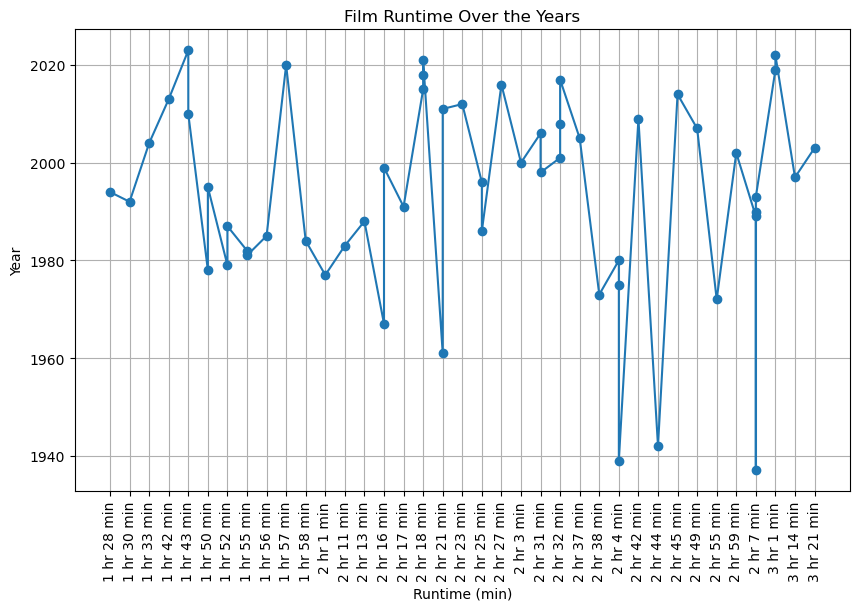

In [18]:
#Sort the DataFrame based on the 'Running Time' column in ascending order
sorted_df = Film_revenue_df.sort_values('Running Time')

#setting the figure size for the line graph
plt.figure(figsize=(10, 6))
#plotting the film runtime over the years using the 'Year' and 'Running Time' columns
#'marker' specifies the marker style of a solid circle for data points, and 'linestyle' specifies a straight, consistent line
plt.plot(sorted_df['Running Time'], sorted_df['Year'], marker='o', linestyle='-')
#setting the title of the line plot
plt.title('Film Runtime Over the Years')
#setting the labels for the x and y axes
plt.xlabel('Runtime (min)')
plt.ylabel('Year')
#rotate the x-axis labels by 90 degrees so that they can be read properly
plt.xticks(rotation=90)
#setting up a grid on the graph to make the markers easier discern which Runtime periods they 
plt.grid(True)
#display the plot with the specified figure size, line graph, title, axis labels, label rotation, and grid lines
plt.show()

#### SQL Database Query #5: 

This is a sql query of the _FilmNom_ data table from the database. Selecting all of the data, but using a WHERE clause to specify only data from years greater than or equal to 1960. (Pandas is not used for this query)

In [19]:
#writing an sql query to pull the FilmNom table data
#using a SELECT * to select all of the table data 
#using a WHERE clause to filter the results to years greater than or equal to 1960
sql5 = """SELECT * FROM FilmNom WHERE Year >= 1960"""

#executing the query
rows = cursor.execute(sql5)
#printing the result set data
for row in rows:
    print(row)

(1372, 'Oppenheimer', 2023, 7, 13, 'True')
(1366, 'Godzilla Minus One', 2023, 1, 1, 'False')
(1360, 'Poor Things', 2023, 4, 11, 'False')
(1361, 'The Zone of Interest', 2023, 2, 5, 'False')
(1362, 'American Fiction', 2023, 1, 5, 'False')
(1364, 'Barbie', 2023, 1, 8, 'False')
(1365, 'The Last Repair Shop', 2023, 1, 1, 'False')
(1363, 'Anatomy of a Fall', 2023, 1, 5, 'False')
(1367, 'The Holdovers', 2023, 1, 5, 'False')
(1368, '20 Days in Mariupol', 2023, 1, 1, 'False')
(1369, 'War Is Over! Inspired by the Music of John and Yoko', 2023, 1, 1, 'False')
(1370, 'The Wonderful Story of Henry Sugar', 2023, 1, 1, 'False')
(1371, 'The Boy and the Heron', 2023, 1, 1, 'False')
(1353, "Guillermo del Toro's Pinocchio", 2022, 1, 1, 'False')
(1347, 'Everything Everywhere All at Once', 2022, 7, 11, 'True')
(1348, 'All Quiet on the Western Front', 2022, 4, 9, 'False')
(1349, 'Top Gun: Maverick', 2022, 1, 6, 'False')
(1350, 'Black Panther: Wakanda Forever', 2022, 1, 5, 'False')
(1351, 'Avatar: The Way of

This is the same query of the _Film_Nom_ table but, this time I will save the data in a Pandas DataFrame to be used when creating a visualization of the data. 

In [20]:
#writing an sql query to join the 2 tables
query5 = """SELECT * FROM FilmNom WHERE Year >= 1960"""

#executing the query and retrieve the result into a pandas DataFrame
FilmNom_df = pd.read_sql_query(query5, conn)
#printing the 'Film_Nom_df' dataframe
FilmNom_df

,Award_id,Film,Year,Awards,Nominations,Best Picture Winner
0,1372,Oppenheimer,2023,7,13.0,True
1,1366,Godzilla Minus One,2023,1,1.0,False
2,1360,Poor Things,2023,4,11.0,False
3,1361,The Zone of Interest,2023,2,5.0,False
4,1362,American Fiction,2023,1,5.0,False
...,...,...,...,...,...,...
903,477,Elmer Gantry,1960,3,5.0,False
904,478,Never on Sunday (Pote tin Kyriaki),1960,1,5.0,False
905,479,The Apartment,1960,5,10.0,True
906,480,The Alamo,1960,1,7.0,False


### Visualization 5: Box Plot
The box plot below provides a visual representation of the distribution of the number of nominations received by films, categorized based on whether they won the "Best Picture" award based on data from the _FilmNom_ dataset. This data shows only data from years greater than or equal to 1960. The box plot enables a visual comparison of the distribution of nominations for "Best Picture Winners" and non-winners. It provides insights into the differences in the spread, central tendency, and potential outliers between the two categories, aiding in the assessment of the relationship between the number of nominations and the "Best Picture Winner" status.

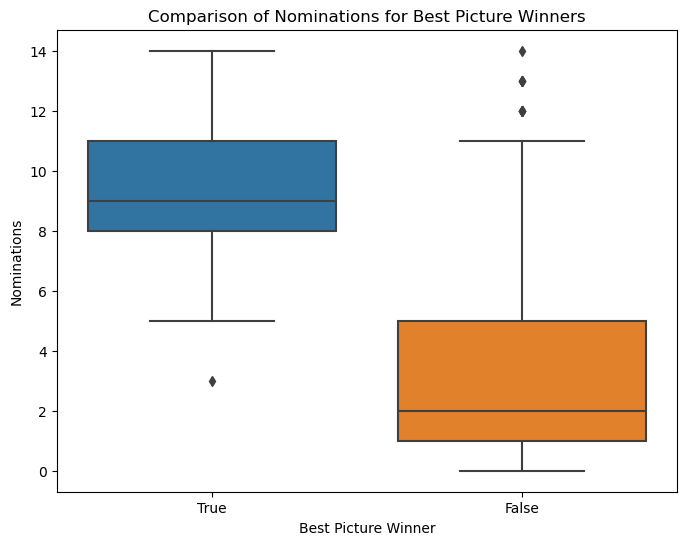

In [21]:
#setting the figure size for the box plot
plt.figure(figsize=(8, 6))
#creating the boxplot with seaborn
#Specifying the data frame, and columns to plot on the x and y axes. 
sns.boxplot(x='Best Picture Winner', y='Nominations', data=FilmNom_df)
#setting a title for the boxplot
plt.title('Comparison of Nominations for Best Picture Winners')
##setting the labels for the x and y axes
plt.xlabel('Best Picture Winner')
plt.ylabel('Nominations')
##display the plot with the specified figure size, boxplot, title, and axis labels
plt.show()

## Displaying the Human Readable Dataset:

At the very first SQL query I made (in code line #7) combined all 3 data tables with an implicit inner join using only SQL and not Pandas. To display the human readable dataset, I will demonstrate the code for using Pandas to create an SQL query for all 3 data tables. Then, I will merge the tables based on the "Year" column and save the data in a Pandas DataFrame. 

In [22]:
#loading the 3 tables into pandas dataframes
table1_df = pd.read_sql_query("SELECT * FROM Holywd_gross", conn)
table2_df = pd.read_sql_query("SELECT * FROM FilmNom", conn)
table3_df = pd.read_sql_query("SELECT * FROM Film_revenue", conn)

#merge the tables based on common keys
merged_df = pd.merge(table1_df, table2_df, on='Year')
merged_df = pd.merge(merged_df, table3_df, on='Year')

#displaying the merged dataframe
merged_df

,Film_x,Year,Release Date,Genre,Rating,Distributor,Running Time,Movie Info,Budget,Domestic Opening,...,production_countries,revenue (USD),budget (USD),popularity,vote_count,vote_average,release_status,tagline,plot,runtime (min)
0,Avatar,2009,16-Dec-09,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",PG-13,Twentieth Century Fox,2 hr 42 min,A paraplegic Marine dispatched to the moon Pan...,"$237,000,000.00","$77,025,481.00",...,"United States of America, United Kingdom","$2,923,706,026.00","$-237,000,000.00",111.323,31119,7.582,Released,Enter the world of Pandora.,"In the 22nd century, a paraplegic Marine is di...",162
1,Avatar,2009,16-Dec-09,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",PG-13,Twentieth Century Fox,2 hr 42 min,A paraplegic Marine dispatched to the moon Pan...,"$237,000,000.00","$77,025,481.00",...,"United States of America, United Kingdom","$2,923,706,026.00","$-237,000,000.00",111.323,31119,7.582,Released,Enter the world of Pandora.,"In the 22nd century, a paraplegic Marine is di...",162
2,Avatar,2009,16-Dec-09,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",PG-13,Twentieth Century Fox,2 hr 42 min,A paraplegic Marine dispatched to the moon Pan...,"$237,000,000.00","$77,025,481.00",...,"United States of America, United Kingdom","$2,923,706,026.00","$-237,000,000.00",111.323,31119,7.582,Released,Enter the world of Pandora.,"In the 22nd century, a paraplegic Marine is di...",162
3,Avatar,2009,16-Dec-09,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",PG-13,Twentieth Century Fox,2 hr 42 min,A paraplegic Marine dispatched to the moon Pan...,"$237,000,000.00","$77,025,481.00",...,"United States of America, United Kingdom","$2,923,706,026.00","$-237,000,000.00",111.323,31119,7.582,Released,Enter the world of Pandora.,"In the 22nd century, a paraplegic Marine is di...",162
4,Avatar,2009,16-Dec-09,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",PG-13,Twentieth Century Fox,2 hr 42 min,A paraplegic Marine dispatched to the moon Pan...,"$237,000,000.00","$77,025,481.00",...,"United States of America, United Kingdom","$2,923,706,026.00","$-237,000,000.00",111.323,31119,7.582,Released,Enter the world of Pandora.,"In the 22nd century, a paraplegic Marine is di...",162
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9721,M3GAN,2022,22-Nov-06,"['Action', 'Crime', 'Sci-Fi', 'Thriller']",PG-13,Universal Pictures,2 hr 6 min,A robotics engineer at a toy company builds a ...,None,"$30,429,860.00",...,United States of America,"$1,488,732,821.00","$-170,000,000.00",185.410,8873,8.200,Released,Feel the need... The need for speed.,After more than thirty years of service as one...,131
9722,M3GAN,2022,22-Nov-06,"['Action', 'Crime', 'Sci-Fi', 'Thriller']",PG-13,Universal Pictures,2 hr 6 min,A robotics engineer at a toy company builds a ...,None,"$30,429,860.00",...,United States of America,"$2,320,250,281.00","$-460,000,000.00",169.075,11554,7.622,Released,Return to Pandora.,Set more than a decade after the events of the...,192
9723,M3GAN,2022,22-Nov-06,"['Action', 'Crime', 'Sci-Fi', 'Thriller']",PG-13,Universal Pictures,2 hr 6 min,A robotics engineer at a toy company builds a ...,None,"$30,429,860.00",...,United States of America,"$1,488,732,821.00","$-170,000,000.00",185.410,8873,8.200,Released,Feel the need... The need for speed.,After more than thirty years of service as one...,131
9724,M3GAN,2022,22-Nov-06,"['Action', 'Crime', 'Sci-Fi', 'Thriller']",PG-13,Universal Pictures,2 hr 6 min,A robotics engineer at a toy company builds a ...,None,"$30,429,860.00",...,United States of America,"$2,320,250,281.00","$-460,000,000.00",169.075,11554,7.622,Released,Return to Pandora.,Set more than a decade after the events of the...,192


## Summary: 

**What I learned and had to do to complete the project**

&emsp; This project gave us a great opportunity to learn how to pull data from 3 very different sources: flat files, websites, and APIs. Once we had successfully pulled the data we needed, formatting the data into a Pandas DataFrame allowed us to use the Pandas library for a wide range of functionalities to handle various data cleaning and preprocessing tasks effectively. One thing that I learned was that not all flat files, websites, or APIs are the same. You have to read the API documentation for each site to learn the specific rules and syntax for pulling the data.  Similarly, websites each have their own html formatting that you must take the time to investigate before attempting to scrape it using BeautifulSoup or pd.read_html. Flat files, such as .csv files also are not always what you expect. During the course we encountered one .csv file that had all of the data crammed into a single column. It required some additional formatting in Excel before we could load the data into a DataFrame using Python. 

&emsp; Some lessons learned when working with both SQL and Python include, that have to be very careful about the changes you make to your data when cleaning it. Just because you have formatted the data to look pretty and organized, doesn’t mean it will be the most effective format for data analysis and visualizations later on. For example, I changed int64 data to monetary format to look better, but after pulling the data back into Python from the database I could not figure out how to convert it back so that it can be used in a visualization without going back to the original notebook file and deleting the initial code. Additionally, when transferring data from SQL to Python the case sensitivity of your columns is essential. For example, I had difficulty joining the data tables back in Python using SQL queries when the primary and foreign key columns did not have exactly the same case sensitivity. This also caused difficulties in creating visualizations as some of them would display blank graphs. 


**What changes were made to the data?**

&emsp; The following changes were made to each set of data during the wrangling and cleaning process: 
* I made 6 cleaning/formatting changes to the flat file data. These include removing duplicate columns, replacing and rearranging headers, handling bad data from the 'Budget' column, finding duplicate entries, editing duplicate movie titles, and editing monetary values into a more readable format.  
* I made 6 changes to the scraped Wikipedia table data. These include finding missing values, finding duplicates, adding a column to address missing data, fixing inconsistent data, and creating a hierarchical index.
* I made 6 cleaning/formatting changes to the flat file data. These include finding missing values and duplicates, replacing and rearranging headers, editing monetary values into a more readable format, formatting other column data into a more readable format, formatting the "release_date" column into DateTime, and creating a "Year" column.  

&emsp; Before adding the data to the DB Browser database, I ended up making a few last-minute formatting changes. I added primary key columns to tables that did not contain column with unique and non-null values. For example, for the FilmNom database I added an “Award_id” column with numerical values that uniquely identified each row of data. I also changed the formatting of some of the primary and foreign key column names to allow them to follow case sensitivity for a smooth transition from the database back into Python.


**Did you make any assumptions in cleaning/transforming the data?**

&emsp; The following assumptions were made for each of the 3 data sets: 
* For the Holywd_gross flat file data, one of the assumptions that I made was that duplicate movie titles in this data were a result of movies that were remade years later. I also assumed that "sales in $" stood for sales in USD, which caused me to format the monetary values to USD. A third assumption that I made was that the non-numerical values in the "Budget" column were an error during the data entry. Without further context on what those entries were, I had to make the decision to change those values to NaN.
* For the FilmNom Wikipedia website data,  an assumption that I made was that each Award season year only had 1 Best Picture winner, and no duplicate winners (or ties). I feel this is a fairly good assumption for the more recent years, however this award show started in the 1930's, so the structure of the award ceremony might have been different back then. Another assumption that I made is that this data is complete. I was able to verify that there were no missing values (NaN) within the dataset, but I was not able to verify that nominated movies were missing from certain award season years.
* For the Film_revenue TMDB API data,  one of the assumptions that I made was that the 'budget' and 'revenue' columns were values in US dollars (USD). A second assumption that I made is that the API request pulled the correct information. For example, that my specific loop and if statement to pull only the movies with the highest revenue worked properly.


**What risks could be created based on the transformations done?**

&emsp; The main risk for all data wrangling and cleaning is that there might be an error in my coding that I did not notice, which might cause the data to be inaccurately calculated or represented. Another risk is that one of the assumptions I made when transforming the data might be incorrect, causing the data to now be represented incorrectly. Two examples of this are: 
* In the Holywd_gross flat file data, if I labeled a movie as a 'Remake' but the movie has a completely different storyline than the original it should not be considered a remake.  
* In the FilmNom Wikipedia website data, when I dropped the extra value in "Award" for the films that had 2 values, I assumed that the first value was the correct value for all of them even though I only verified the first few.


**How was your data sourced / verified for credibility?**

&emsp; Even though each of the 3 sets of data were all related to film information, investigation should be done to verify the credibility of the data from each source. The majority of the data for this project was originally sourced from movie websites such as IMDB, rotten tomatoes and other movie information sites. . These sites are mainly focused on user-driven (viewers and critics) ratings. However, websites such as IMDB are known as the most popular and authoritative source for movie, TV, and celebrity content. Data from websites such as Wikipedia, however, do require skepticism because anyone can edit the material on a Wikipedia page at any time, and it's not safe to assume that information has been checked before publication. One way that I was able to verify the integrity of the data was through the identification of missing values. Checking for missing values allows you to understand the extent of missing data so that you can take the appropriate actions to address it. Additionally, you can go to the original source of the data for accuracy verification, which in this case was the Academy of Motion Picture Arts and Sciences website. 


**Was your data acquired in an ethical way?**

&emsp; The data on film database websites is readily available to the public, and many of them have supporting APIs to assist users in pulling data. As long as these websites are following any copyright or creative commons requirements for film related data, then there would be no reason to believe this data was not sourced in an ethical way.


**Are there any legal or regulatory guidelines for your data or project topic?**

&emsp; I have not found any legal or regulatory guidelines regarding the use of film data specifically. However, if any personal identifying information is used, it must be handled in accordance with current data privacy laws and in some cases, consent may be required to use personal data. However, the PII information published on IMBD, Rotten Tomatoes, Academy of Motion Picture Arts and Sciences website, and the other movie information sites has already been scrutinized based on the current laws and regulations. The main legal guidelines I would need to focus on when using this data is whether I am following the individual website's copyright and creative commons requirements. For example, the TMDB API is free to use for non-commercial purposes, and users are required to attribute TMDB as the source of the data and/or images when using the API. So, am compliant as long as I am referencing TMDB as my source and not trying to make money off of the utilization of the data.


**How would you mitigate any of the ethical implications you have identified?**

&emsp; In order to mitigate any ethical implications when working with this data, it is important that I am aware of any potential biases and that I do not attempt to preserve any existing biases. Transparency is essential, and it is important to take steps to prevent data manipulation or misrepresentation that could lead to misleading conclusions or unfair treatment. I will need to exercise caution and responsibility in the interpretation and reporting of the results to avoid any harm or negative consequences to the individuals and film companies this data is about.